#  Exploratory Data Analysis (EDA)

## HR Alto Network Employee Attrition Project

### Goal
Explore the cleaned HR dataset, understand employee distributions, analyze attrition, examine career progression, compare departments, study numerical relationships, and summarize key business findings.

> Output CSVs and images can be saved later. This notebook focuses on the analysis.


## Workflow

```text
1. Load Cleaned Dataset
        ↓
2. Dataset Overview
        ↓
3. Univariate Analysis
        ↓
4. Attrition Analysis
        ↓
5. Career Progression Analysis
        ↓
6. Department-Level Analysis
        ↓
7. Correlation Analysis
        ↓
8. Key Business Insights
```


# 1. Load Cleaned Dataset

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

candidate_paths = [
    Path("../data/cleaned/Palo Alto Networks_cleaned.csv"),
    Path("../data/cleaned/Palo Alto Networks.csv"),
    Path("../data/Palo Alto Networks_cleaned.csv"),
    Path("../data/Palo Alto Networks.csv"),
    Path("Palo Alto Networks_cleaned.csv"),
    Path("Palo Alto Networks.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Cleaned dataset not found. Update candidate_paths with the correct path."
    )

df = pd.read_csv(data_path)

print("Cleaned dataset loaded successfully.")
print("Shape:", df.shape)


Cleaned dataset loaded successfully.
Shape: (1470, 31)


# 2. Dataset Overview

In [2]:
display(df.head())
print("\nShape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("Data_Type"))


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2



Shape: (1470, 31)

Data types:


,Data_Type
Age,int64
Attrition,int64
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EnvironmentSatisfaction,int64
Gender,object


In [3]:
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

display(df.describe().T)


Missing values: 0
Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
Attrition,1470.0,0.161224,0.367863,0.0,0.0,0.0,0.00,1.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0


# 3. Univariate Analysis

Analyze one variable at a time.

## 3.1 Age


count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64


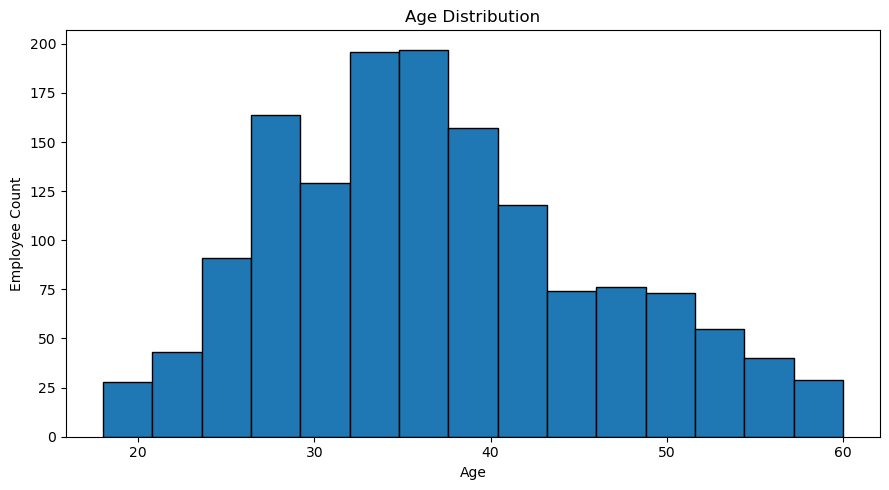

In [4]:
print(df["Age"].describe())

plt.figure(figsize=(9, 5))
plt.hist(df["Age"], bins=15, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Employee Count")
plt.tight_layout()
plt.show()


## 3.2 Department

,Department,Employee_Count,Percentage
0,Research & Development,961,65.37
1,Sales,446,30.34
2,Human Resources,63,4.29


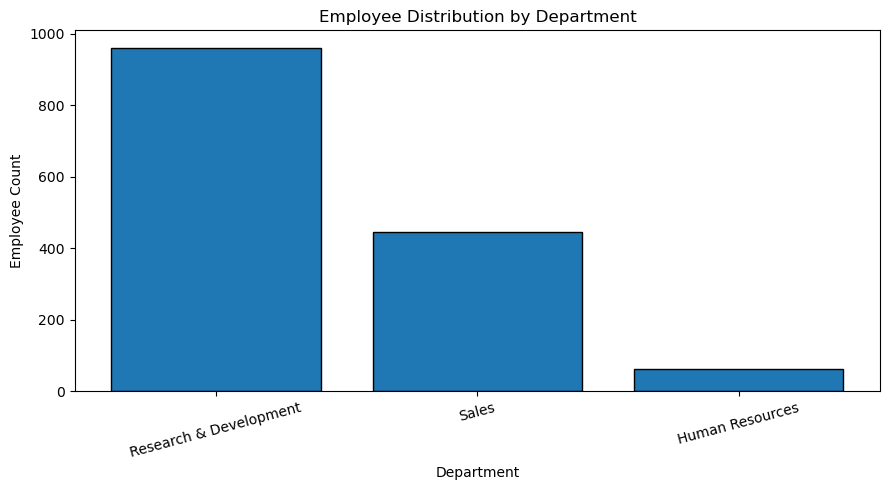

In [5]:
department_summary = (
    df["Department"]
    .value_counts()
    .rename_axis("Department")
    .reset_index(name="Employee_Count")
)

department_summary["Percentage"] = (
    department_summary["Employee_Count"]
    / len(df) * 100
).round(2)

display(department_summary)

plt.figure(figsize=(9, 5))
plt.bar(
    department_summary["Department"],
    department_summary["Employee_Count"],
    edgecolor="black"
)
plt.title("Employee Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 3.3 Job Role

,JobRole,Employee_Count,Percentage
0,Sales Executive,326,22.18
1,Research Scientist,292,19.86
2,Laboratory Technician,259,17.62
3,Manufacturing Director,145,9.86
4,Healthcare Representative,131,8.91
5,Manager,102,6.94
6,Sales Representative,83,5.65
7,Research Director,80,5.44
8,Human Resources,52,3.54


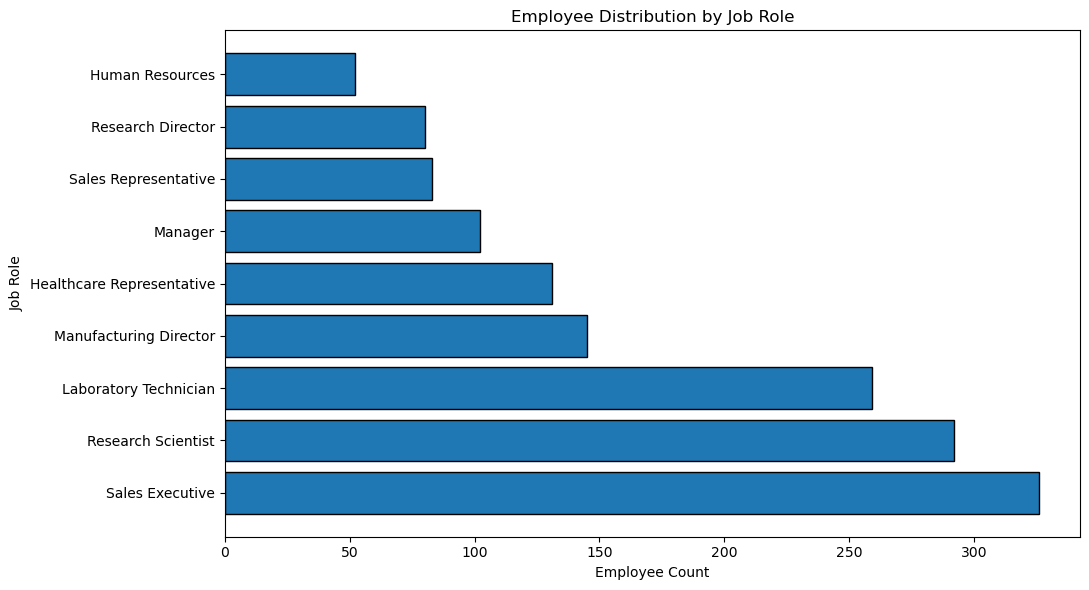

In [6]:
job_role_summary = (
    df["JobRole"]
    .value_counts()
    .rename_axis("JobRole")
    .reset_index(name="Employee_Count")
)

job_role_summary["Percentage"] = (
    job_role_summary["Employee_Count"]
    / len(df) * 100
).round(2)

display(job_role_summary)

plt.figure(figsize=(11, 6))
plt.barh(
    job_role_summary["JobRole"],
    job_role_summary["Employee_Count"],
    edgecolor="black"
)
plt.title("Employee Distribution by Job Role")
plt.xlabel("Employee Count")
plt.ylabel("Job Role")
plt.tight_layout()
plt.show()


## 3.4 Job Level

,JobLevel,Employee_Count,Percentage
0,1,543,36.94
1,2,534,36.33
2,3,218,14.83
3,4,106,7.21
4,5,69,4.69


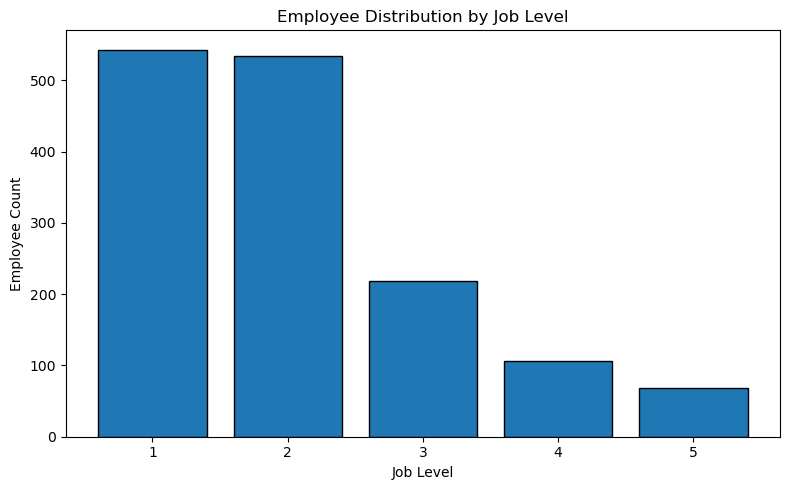

In [7]:
job_level_summary = (
    df["JobLevel"]
    .value_counts()
    .sort_index()
    .rename_axis("JobLevel")
    .reset_index(name="Employee_Count")
)

job_level_summary["Percentage"] = (
    job_level_summary["Employee_Count"]
    / len(df) * 100
).round(2)

display(job_level_summary)

plt.figure(figsize=(8, 5))
plt.bar(
    job_level_summary["JobLevel"].astype(str),
    job_level_summary["Employee_Count"],
    edgecolor="black"
)
plt.title("Employee Distribution by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Employee Count")
plt.tight_layout()
plt.show()


## 3.5 Career Variables

Analyze the main career-duration variables:

- `TotalWorkingYears`
- `YearsInCurrentRole`
- `YearsSinceLastPromotion`
- `YearsWithCurrManager`

`YearsAtCompany` is retained for reference but should be interpreted carefully because Day 2 identified logical inconsistencies involving this field.


In [8]:
career_columns = [
    "TotalWorkingYears",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

display(df[career_columns].describe().T)


,count,mean,std,min,25%,50%,75%,max
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.0,40.0
YearsInCurrentRole,1470.0,4.229252,3.623137,0.0,2.0,3.0,7.0,18.0
YearsSinceLastPromotion,1470.0,2.187755,3.222430,0.0,0.0,1.0,3.0,15.0
YearsWithCurrManager,1470.0,4.123129,3.568136,0.0,2.0,3.0,7.0,17.0


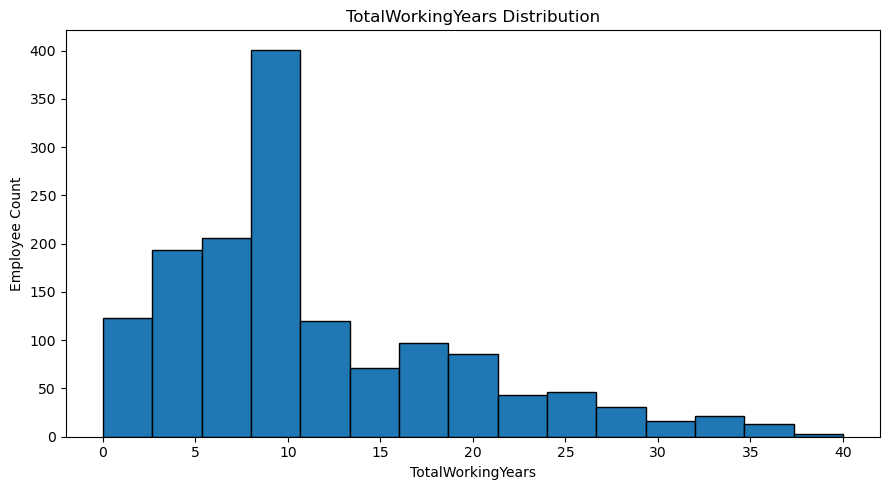

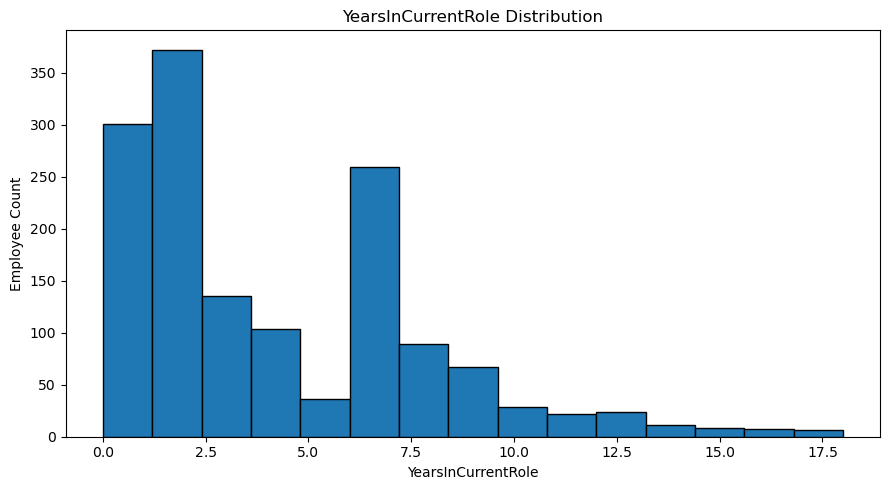

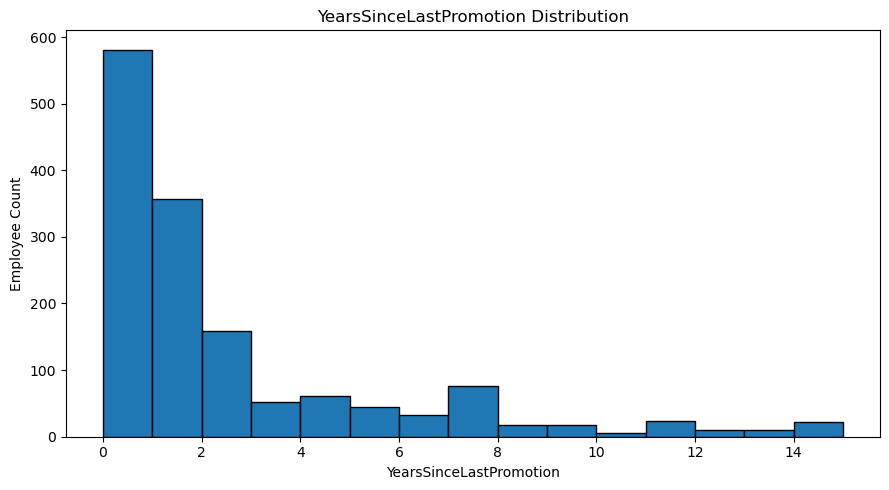

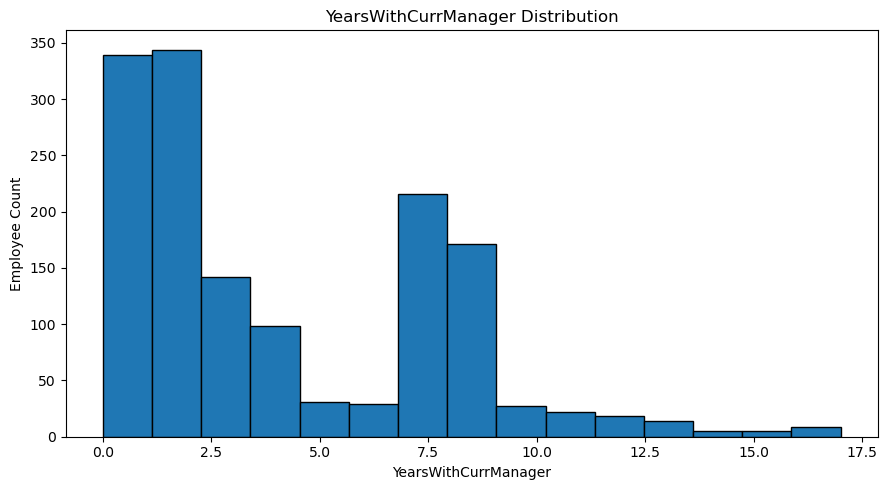

In [9]:
for col in career_columns:
    plt.figure(figsize=(9, 5))
    plt.hist(df[col], bins=15, edgecolor="black")
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Employee Count")
    plt.tight_layout()
    plt.show()


## 3.6 Training

,TrainingTimesLastYear,Employee_Count,Percentage
0,0,54,3.67
1,1,71,4.83
2,2,547,37.21
3,3,491,33.40
4,4,123,8.37
5,5,119,8.10
6,6,65,4.42


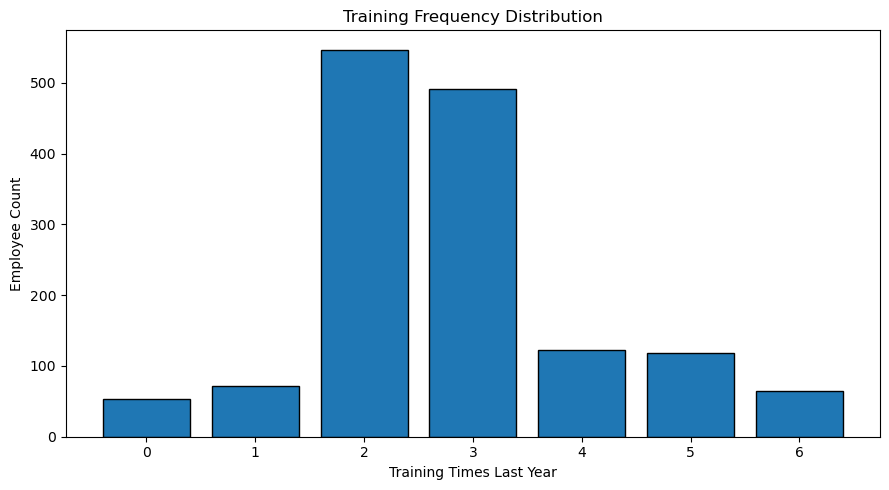

In [10]:
training_summary = (
    df["TrainingTimesLastYear"]
    .value_counts()
    .sort_index()
    .rename_axis("TrainingTimesLastYear")
    .reset_index(name="Employee_Count")
)

training_summary["Percentage"] = (
    training_summary["Employee_Count"]
    / len(df) * 100
).round(2)

display(training_summary)

plt.figure(figsize=(9, 5))
plt.bar(
    training_summary["TrainingTimesLastYear"].astype(str),
    training_summary["Employee_Count"],
    edgecolor="black"
)
plt.title("Training Frequency Distribution")
plt.xlabel("Training Times Last Year")
plt.ylabel("Employee Count")
plt.tight_layout()
plt.show()


# 4. Attrition Analysis

## 4.1 Overall Attrition


,Metric,Value
0,Total Employees,1470.00
1,Employees Stayed,1233.00
2,Employees Left,237.00
3,Attrition Rate (%),16.12


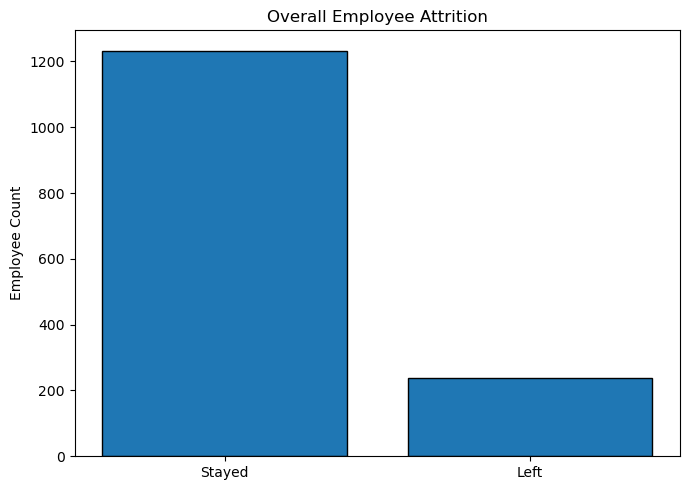

In [11]:
overall_attrition = pd.DataFrame({
    "Metric": [
        "Total Employees",
        "Employees Stayed",
        "Employees Left",
        "Attrition Rate (%)"
    ],
    "Value": [
        len(df),
        int((df["Attrition"] == 0).sum()),
        int((df["Attrition"] == 1).sum()),
        round(df["Attrition"].mean() * 100, 2)
    ]
})

display(overall_attrition)

plt.figure(figsize=(7, 5))
plt.bar(
    ["Stayed", "Left"],
    [
        (df["Attrition"] == 0).sum(),
        (df["Attrition"] == 1).sum()
    ],
    edgecolor="black"
)
plt.title("Overall Employee Attrition")
plt.ylabel("Employee Count")
plt.tight_layout()
plt.show()


## 4.2 Attrition by Department

,Department,Total_Employees,Employees_Left,Attrition_Rate (%)
0,Human Resources,63,12,19.05
1,Research & Development,961,133,13.84
2,Sales,446,92,20.63


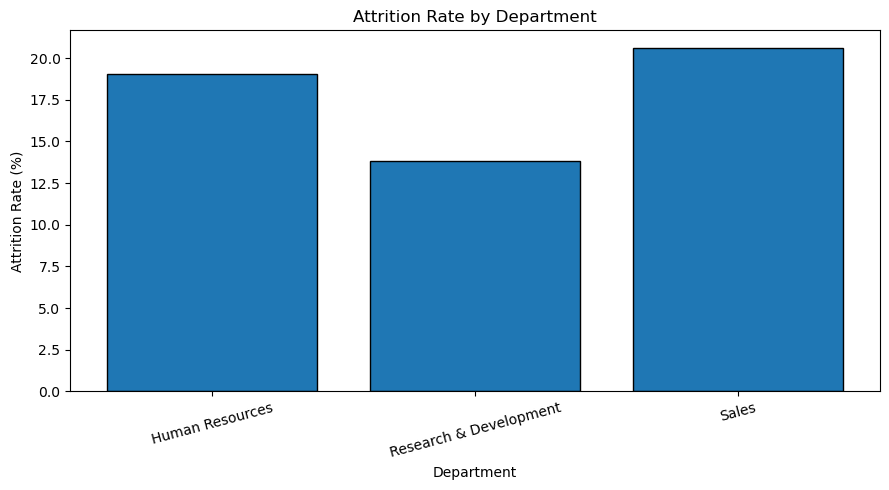

In [12]:
department_attrition = (
    df.groupby("Department")
      .agg(
          Total_Employees=("Attrition", "count"),
          Employees_Left=("Attrition", "sum")
      )
      .reset_index()
)

department_attrition["Attrition_Rate (%)"] = (
    department_attrition["Employees_Left"]
    / department_attrition["Total_Employees"] * 100
).round(2)

display(department_attrition)

plt.figure(figsize=(9, 5))
plt.bar(
    department_attrition["Department"],
    department_attrition["Attrition_Rate (%)"],
    edgecolor="black"
)
plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 4.3 Attrition by Job Role

,JobRole,Total_Employees,Employees_Left,Attrition_Rate (%)
8,Sales Representative,83,33,39.76
2,Laboratory Technician,259,62,23.94
1,Human Resources,52,12,23.08
7,Sales Executive,326,57,17.48
6,Research Scientist,292,47,16.10
4,Manufacturing Director,145,10,6.90
0,Healthcare Representative,131,9,6.87
3,Manager,102,5,4.90
5,Research Director,80,2,2.50


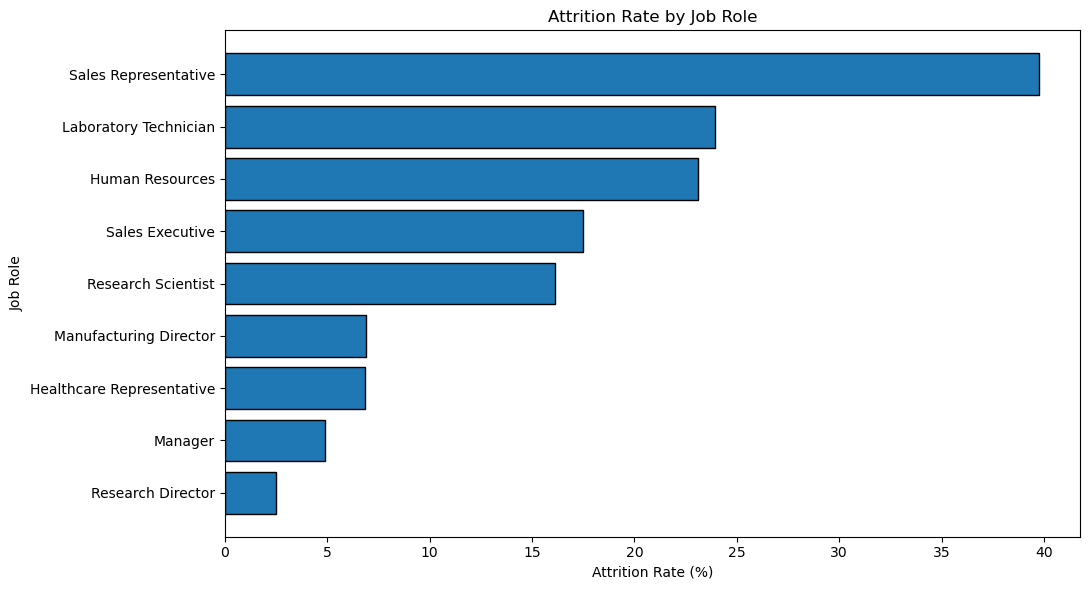

In [13]:
job_role_attrition = (
    df.groupby("JobRole")
      .agg(
          Total_Employees=("Attrition", "count"),
          Employees_Left=("Attrition", "sum")
      )
      .reset_index()
)

job_role_attrition["Attrition_Rate (%)"] = (
    job_role_attrition["Employees_Left"]
    / job_role_attrition["Total_Employees"] * 100
).round(2)

display(
    job_role_attrition.sort_values(
        "Attrition_Rate (%)",
        ascending=False
    )
)

plt.figure(figsize=(11, 6))
plot_data = job_role_attrition.sort_values("Attrition_Rate (%)")
plt.barh(
    plot_data["JobRole"],
    plot_data["Attrition_Rate (%)"],
    edgecolor="black"
)
plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.tight_layout()
plt.show()


## 4.4 Attrition by Job Level

,JobLevel,Total_Employees,Employees_Left,Attrition_Rate (%)
0,1,543,143,26.34
1,2,534,52,9.74
2,3,218,32,14.68
3,4,106,5,4.72
4,5,69,5,7.25


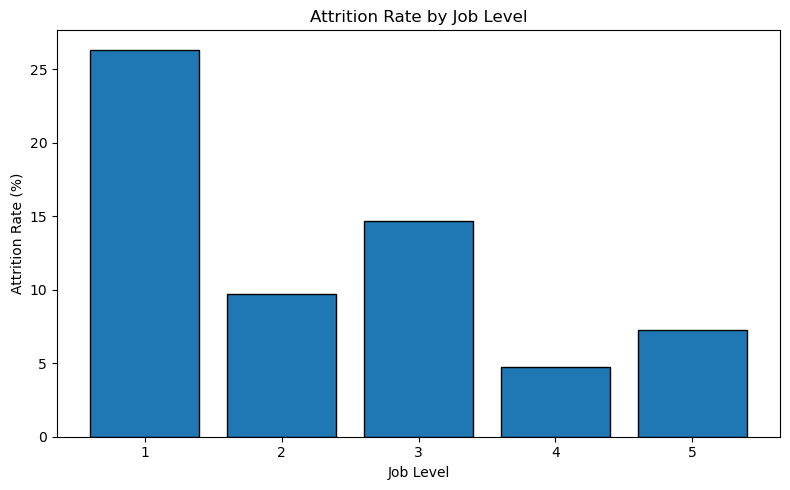

In [14]:
job_level_attrition = (
    df.groupby("JobLevel")
      .agg(
          Total_Employees=("Attrition", "count"),
          Employees_Left=("Attrition", "sum")
      )
      .reset_index()
)

job_level_attrition["Attrition_Rate (%)"] = (
    job_level_attrition["Employees_Left"]
    / job_level_attrition["Total_Employees"] * 100
).round(2)

display(job_level_attrition)

plt.figure(figsize=(8, 5))
plt.bar(
    job_level_attrition["JobLevel"].astype(str),
    job_level_attrition["Attrition_Rate (%)"],
    edgecolor="black"
)
plt.title("Attrition Rate by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.show()


# 5. Career Progression Analysis

Create interpretable groups for promotion gaps and role duration.

> These groups are for analysis and do not automatically label an employee as stagnating.


In [15]:
# Promotion Gap Group
promotion_bins = [-1, 1, 3, 5, np.inf]
promotion_labels = ["0–1 Years", "2–3 Years", "4–5 Years", "6+ Years"]

df["PromotionGapGroup"] = pd.cut(
    df["YearsSinceLastPromotion"],
    bins=promotion_bins,
    labels=promotion_labels
)

# Role Duration Group
role_bins = [-1, 2, 5, 10, np.inf]
role_labels = ["0–2 Years", "3–5 Years", "6–10 Years", "11+ Years"]

df["RoleDurationGroup"] = pd.cut(
    df["YearsInCurrentRole"],
    bins=role_bins,
    labels=role_labels
)

# Training Group
training_bins = [-1, 0, 2, 4, np.inf]
training_labels = ["No Training", "Low Training", "Moderate Training", "High Training"]

df["TrainingGroup"] = pd.cut(
    df["TrainingTimesLastYear"],
    bins=training_bins,
    labels=training_labels
)

display(df[
    [
        "YearsSinceLastPromotion",
        "PromotionGapGroup",
        "YearsInCurrentRole",
        "RoleDurationGroup",
        "TrainingTimesLastYear",
        "TrainingGroup"
    ]
].head())


,YearsSinceLastPromotion,PromotionGapGroup,YearsInCurrentRole,RoleDurationGroup,TrainingTimesLastYear,TrainingGroup
0,0,0–1 Years,4,3–5 Years,0,No Training
1,1,0–1 Years,7,6–10 Years,3,Moderate Training
2,0,0–1 Years,0,0–2 Years,3,Moderate Training
3,3,2–3 Years,7,6–10 Years,3,Moderate Training
4,2,2–3 Years,2,0–2 Years,3,Moderate Training


## 5.1 Promotion Gap

In [16]:
promotion_gap_summary = (
    df.groupby("PromotionGapGroup", observed=False)
      .size()
      .reset_index(name="Employee_Count")
)

promotion_gap_summary["Percentage"] = (
    promotion_gap_summary["Employee_Count"]
    / len(df) * 100
).round(2)

display(promotion_gap_summary)


,PromotionGapGroup,Employee_Count,Percentage
0,0–1 Years,938,63.81
1,2–3 Years,211,14.35
2,4–5 Years,106,7.21
3,6+ Years,215,14.63


## 5.2 Role Stagnation

In [17]:
role_stagnation_summary = (
    df.groupby("RoleDurationGroup", observed=False)
      .size()
      .reset_index(name="Employee_Count")
)

role_stagnation_summary["Percentage"] = (
    role_stagnation_summary["Employee_Count"]
    / len(df) * 100
).round(2)

display(role_stagnation_summary)


,RoleDurationGroup,Employee_Count,Percentage
0,0–2 Years,673,45.78
1,3–5 Years,275,18.71
2,6–10 Years,444,30.20
3,11+ Years,78,5.31


## 5.3 Promotion Gap vs Attrition

,PromotionGapGroup,Total_Employees,Employees_Left,Attrition_Rate (%)
0,0–1 Years,938,159,16.95
1,2–3 Years,211,36,17.06
2,4–5 Years,106,7,6.60
3,6+ Years,215,35,16.28


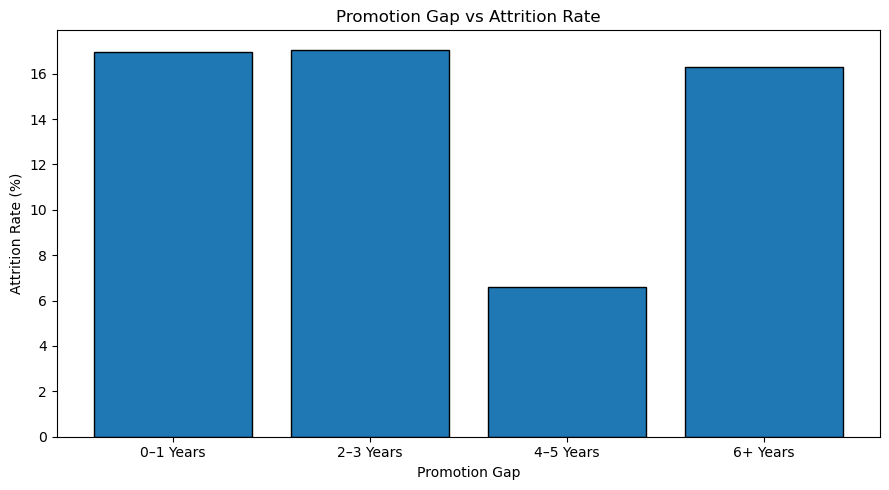

In [18]:
promotion_attrition = (
    df.groupby("PromotionGapGroup", observed=False)
      .agg(
          Total_Employees=("Attrition", "count"),
          Employees_Left=("Attrition", "sum")
      )
      .reset_index()
)

promotion_attrition["Attrition_Rate (%)"] = (
    promotion_attrition["Employees_Left"]
    / promotion_attrition["Total_Employees"] * 100
).round(2)

display(promotion_attrition)

plt.figure(figsize=(9, 5))
plt.bar(
    promotion_attrition["PromotionGapGroup"].astype(str),
    promotion_attrition["Attrition_Rate (%)"],
    edgecolor="black"
)
plt.title("Promotion Gap vs Attrition Rate")
plt.xlabel("Promotion Gap")
plt.ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.show()


## 5.4 Role Duration vs Attrition

In [19]:
role_duration_attrition = (
    df.groupby("RoleDurationGroup", observed=False)
      .agg(
          Total_Employees=("Attrition", "count"),
          Employees_Left=("Attrition", "sum")
      )
      .reset_index()
)

role_duration_attrition["Attrition_Rate (%)"] = (
    role_duration_attrition["Employees_Left"]
    / role_duration_attrition["Total_Employees"] * 100
).round(2)

display(role_duration_attrition)


,RoleDurationGroup,Total_Employees,Employees_Left,Attrition_Rate (%)
0,0–2 Years,673,152,22.59
1,3–5 Years,275,32,11.64
2,6–10 Years,444,48,10.81
3,11+ Years,78,5,6.41


## 5.5 Training vs Career Progression

In [20]:
training_promotion = (
    df.groupby("PromotionGapGroup", observed=False)
      .agg(
          Employee_Count=("TrainingTimesLastYear", "count"),
          Average_Training=("TrainingTimesLastYear", "mean"),
          Median_Training=("TrainingTimesLastYear", "median")
      )
      .reset_index()
)

training_promotion["Average_Training"] = (
    training_promotion["Average_Training"].round(2)
)

display(training_promotion)

training_role_duration = (
    df.groupby("RoleDurationGroup", observed=False)
      .agg(
          Employee_Count=("TrainingTimesLastYear", "count"),
          Average_Training=("TrainingTimesLastYear", "mean"),
          Median_Training=("TrainingTimesLastYear", "median")
      )
      .reset_index()
)

training_role_duration["Average_Training"] = (
    training_role_duration["Average_Training"].round(2)
)

display(training_role_duration)


,PromotionGapGroup,Employee_Count,Average_Training,Median_Training
0,0–1 Years,938,2.79,3.0
1,2–3 Years,211,2.78,3.0
2,4–5 Years,106,2.96,3.0
3,6+ Years,215,2.78,3.0


,RoleDurationGroup,Employee_Count,Average_Training,Median_Training
0,0–2 Years,673,2.77,3.0
1,3–5 Years,275,2.87,3.0
2,6–10 Years,444,2.84,3.0
3,11+ Years,78,2.63,3.0


# 6. Department-Level Analysis

In [21]:
department_summary = (
    df.groupby("Department")
      .agg(
          Total_Employees=("Attrition", "count"),
          Employees_Left=("Attrition", "sum"),
          Average_Monthly_Income=("MonthlyIncome", "mean"),
          Average_Job_Satisfaction=("JobSatisfaction", "mean"),
          Average_WorkLife_Balance=("WorkLifeBalance", "mean"),
          Average_Training=("TrainingTimesLastYear", "mean"),
          Average_Years_Since_Last_Promotion=("YearsSinceLastPromotion", "mean"),
          Average_Years_In_Current_Role=("YearsInCurrentRole", "mean")
      )
      .reset_index()
)

department_summary["Attrition_Rate (%)"] = (
    department_summary["Employees_Left"]
    / department_summary["Total_Employees"] * 100
).round(2)

round_columns = [
    "Average_Monthly_Income",
    "Average_Job_Satisfaction",
    "Average_WorkLife_Balance",
    "Average_Training",
    "Average_Years_Since_Last_Promotion",
    "Average_Years_In_Current_Role"
]

department_summary[round_columns] = (
    department_summary[round_columns].round(2)
)

display(department_summary)


,Department,Total_Employees,Employees_Left,Average_Monthly_Income,Average_Job_Satisfaction,Average_WorkLife_Balance,Average_Training,Average_Years_Since_Last_Promotion,Average_Years_In_Current_Role,Attrition_Rate (%)
0,Human Resources,63,12,6654.51,2.60,2.92,2.56,1.78,3.54,19.05
1,Research & Development,961,133,6281.25,2.73,2.73,2.79,2.14,4.16,13.84
2,Sales,446,92,6959.17,2.75,2.82,2.85,2.35,4.49,20.63


# 7. Correlation Analysis

In [22]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

correlation_matrix = (
    df[numerical_columns]
    .corr()
    .round(2)
)

display(correlation_matrix)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.00,-0.16,0.01,-0.00,0.21,0.01,0.02,0.03,0.51,-0.00,...,0.00,0.05,0.04,0.68,-0.02,-0.02,0.31,0.21,0.22,0.20
Attrition,-0.16,1.00,-0.06,0.08,-0.03,-0.10,-0.01,-0.13,-0.17,-0.10,...,0.00,-0.05,-0.14,-0.17,-0.06,-0.06,-0.13,-0.16,-0.03,-0.16
DailyRate,0.01,-0.06,1.00,-0.00,-0.02,0.02,0.02,0.05,0.00,0.03,...,0.00,0.01,0.04,0.01,0.00,-0.04,-0.03,0.01,-0.03,-0.03
DistanceFromHome,-0.00,0.08,-0.00,1.00,0.02,-0.02,0.03,0.01,0.01,-0.00,...,0.03,0.01,0.04,0.00,-0.04,-0.03,0.01,0.02,0.01,0.01
Education,0.21,-0.03,-0.02,0.02,1.00,-0.03,0.02,0.04,0.10,-0.01,...,-0.02,-0.01,0.02,0.15,-0.03,0.01,0.07,0.06,0.05,0.07
EnvironmentSatisfaction,0.01,-0.10,0.02,-0.02,-0.03,1.00,-0.05,-0.01,0.00,-0.01,...,-0.03,0.01,0.00,-0.00,-0.02,0.03,0.00,0.02,0.02,-0.00
HourlyRate,0.02,-0.01,0.02,0.03,0.02,-0.05,1.00,0.04,-0.03,-0.07,...,-0.00,0.00,0.05,-0.00,-0.01,-0.00,-0.02,-0.02,-0.03,-0.02
JobInvolvement,0.03,-0.13,0.05,0.01,0.04,-0.01,0.04,1.00,-0.01,-0.02,...,-0.03,0.03,0.02,-0.01,-0.02,-0.01,-0.02,0.01,-0.02,0.03
JobLevel,0.51,-0.17,0.00,0.01,0.10,0.00,-0.03,-0.01,1.00,-0.00,...,-0.02,0.02,0.01,0.78,-0.02,0.04,0.53,0.39,0.35,0.38
JobSatisfaction,-0.00,-0.10,0.03,-0.00,-0.01,-0.01,-0.07,-0.02,-0.00,1.00,...,0.00,-0.01,0.01,-0.02,-0.01,-0.02,-0.00,-0.00,-0.02,-0.03


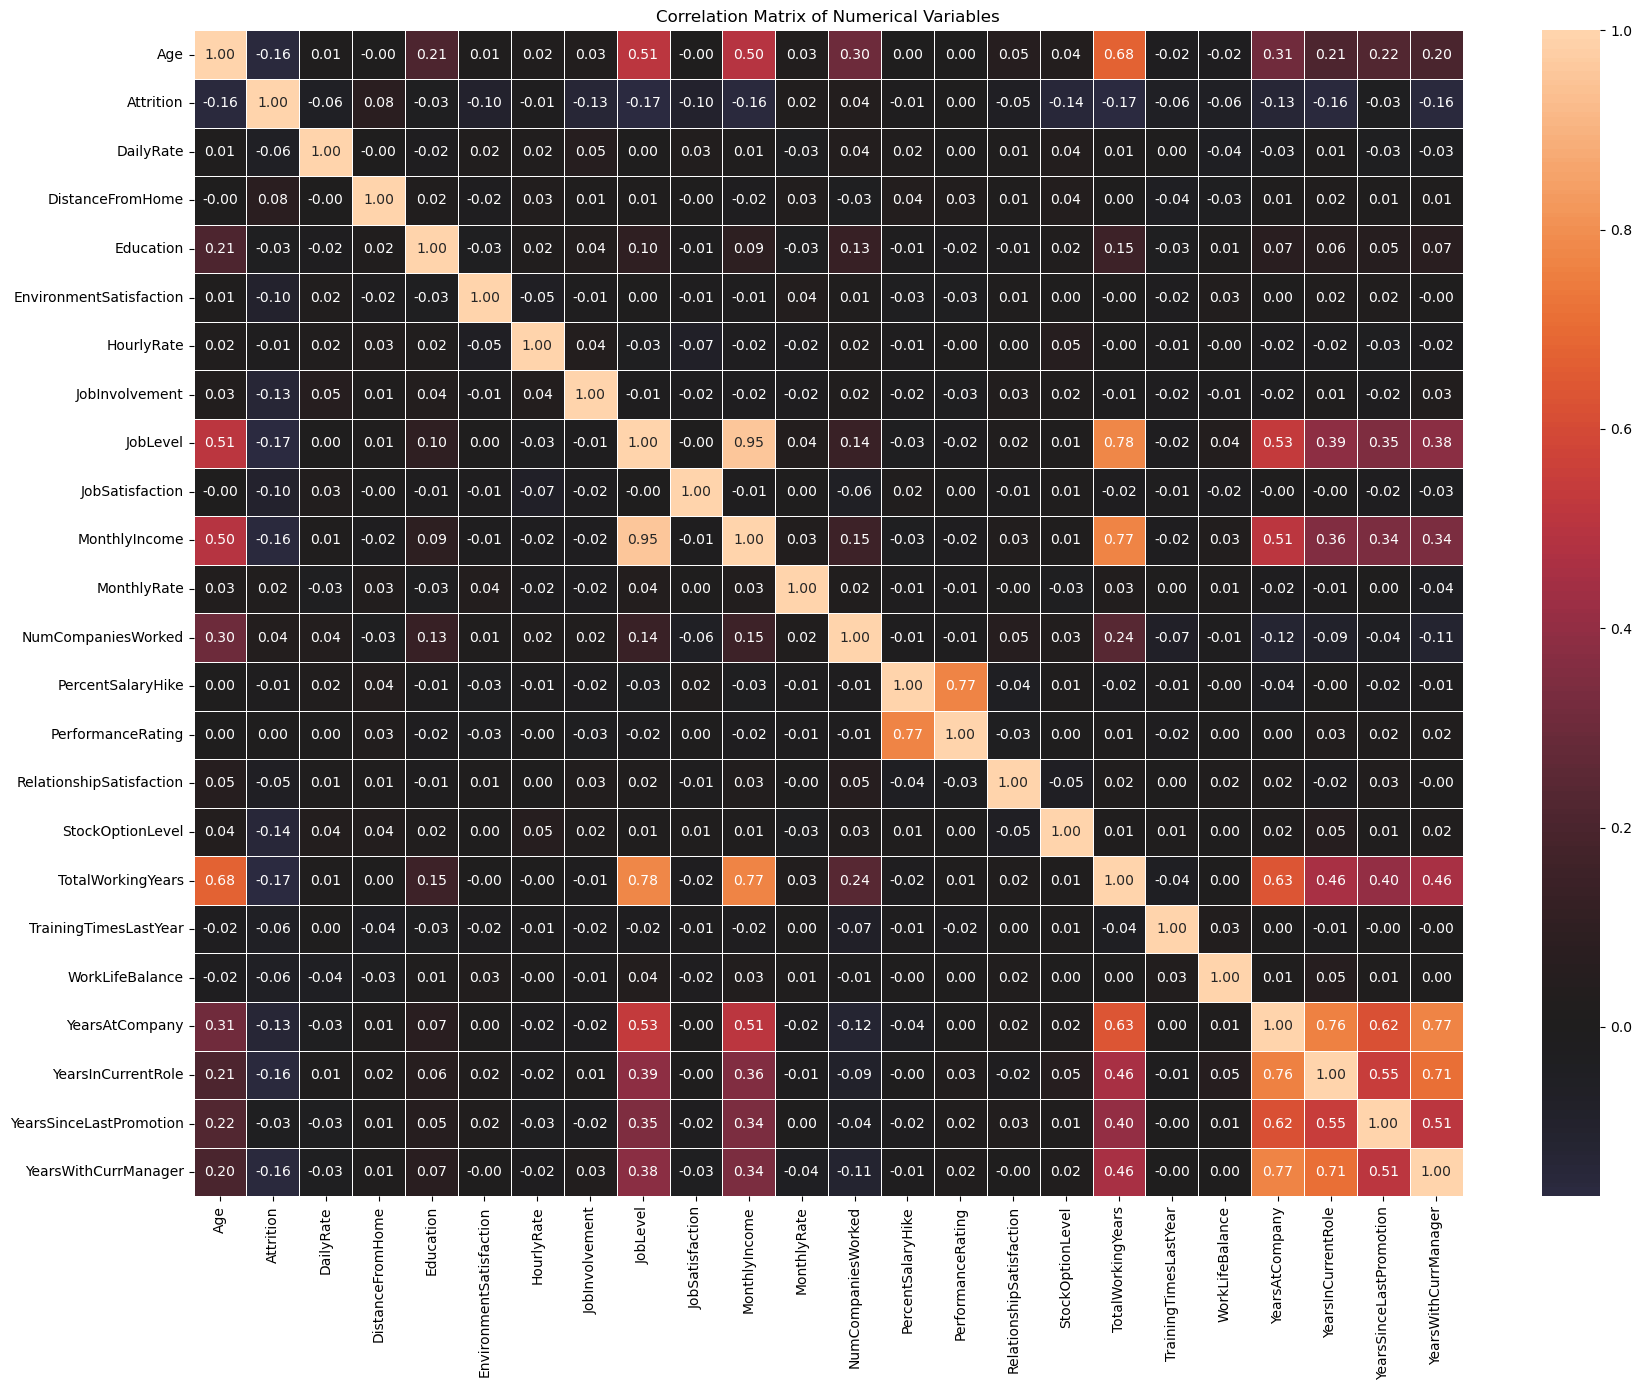

In [23]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()


In [24]:
attrition_correlation = (
    correlation_matrix["Attrition"]
    .drop("Attrition")
    .sort_values()
)

attrition_correlation_table = (
    attrition_correlation
    .reset_index()
)

attrition_correlation_table.columns = [
    "Variable",
    "Correlation_With_Attrition"
]

attrition_correlation_table["Absolute_Correlation"] = (
    attrition_correlation_table["Correlation_With_Attrition"].abs()
)

attrition_correlation_table = (
    attrition_correlation_table
    .sort_values("Absolute_Correlation", ascending=False)
    .reset_index(drop=True)
)

display(attrition_correlation_table)


,Variable,Correlation_With_Attrition,Absolute_Correlation
0,TotalWorkingYears,-0.17,0.17
1,JobLevel,-0.17,0.17
2,Age,-0.16,0.16
3,YearsInCurrentRole,-0.16,0.16
4,MonthlyIncome,-0.16,0.16
5,YearsWithCurrManager,-0.16,0.16
6,StockOptionLevel,-0.14,0.14
7,JobInvolvement,-0.13,0.13
8,YearsAtCompany,-0.13,0.13
9,EnvironmentSatisfaction,-0.10,0.10


# 8. Key Business Insights

In [25]:
# Automatically extract the strongest findings from completed analyses.
overall_rate = round(df["Attrition"].mean() * 100, 2)

highest_department = department_attrition.loc[
    department_attrition["Attrition_Rate (%)"].idxmax()
]

highest_job_role = job_role_attrition.loc[
    job_role_attrition["Attrition_Rate (%)"].idxmax()
]

highest_job_level = job_level_attrition.loc[
    job_level_attrition["Attrition_Rate (%)"].idxmax()
]

highest_promotion_gap = promotion_attrition.loc[
    promotion_attrition["Attrition_Rate (%)"].idxmax()
]

highest_role_duration = role_duration_attrition.loc[
    role_duration_attrition["Attrition_Rate (%)"].idxmax()
]

lowest_satisfaction_department = department_summary.loc[
    department_summary["Average_Job_Satisfaction"].idxmin()
]

lowest_worklife_department = department_summary.loc[
    department_summary["Average_WorkLife_Balance"].idxmin()
]

top_attrition_correlation = attrition_correlation_table.iloc[0]

key_business_insights = pd.DataFrame([
    {
        "Insight_Area": "Overall Attrition",
        "Key_Insight": f"Overall attrition rate is {overall_rate}%.",
        "Business_Implication": "This provides the baseline for retention analysis."
    },
    {
        "Insight_Area": "Department Attrition",
        "Key_Insight": (
            f"{highest_department['Department']} has the highest attrition "
            f"rate at {highest_department['Attrition_Rate (%)']}%."
        ),
        "Business_Implication": "This department should be investigated further for retention factors."
    },
    {
        "Insight_Area": "Job Role Attrition",
        "Key_Insight": (
            f"{highest_job_role['JobRole']} has the highest attrition rate "
            f"at {highest_job_role['Attrition_Rate (%)']}%."
        ),
        "Business_Implication": "This role represents a potential retention-risk group."
    },
    {
        "Insight_Area": "Job Level Attrition",
        "Key_Insight": (
            f"Job Level {highest_job_level['JobLevel']} has the highest "
            f"attrition rate at {highest_job_level['Attrition_Rate (%)']}%."
        ),
        "Business_Implication": "Employees at this level may need further retention analysis."
    },
    {
        "Insight_Area": "Promotion Gap vs Attrition",
        "Key_Insight": (
            f"The {highest_promotion_gap['PromotionGapGroup']} promotion-gap "
            f"group has the highest attrition rate at "
            f"{highest_promotion_gap['Attrition_Rate (%)']}%."
        ),
        "Business_Implication": "This shows an association worth investigating further."
    },
    {
        "Insight_Area": "Role Duration vs Attrition",
        "Key_Insight": (
            f"The {highest_role_duration['RoleDurationGroup']} role-duration "
            f"group has the highest attrition rate at "
            f"{highest_role_duration['Attrition_Rate (%)']}%."
        ),
        "Business_Implication": "This group may warrant additional career-progression analysis."
    },
    {
        "Insight_Area": "Department Satisfaction",
        "Key_Insight": (
            f"{lowest_satisfaction_department['Department']} has the lowest "
            f"average job satisfaction."
        ),
        "Business_Implication": "Employee experience factors should be investigated in this department."
    },
    {
        "Insight_Area": "Work-Life Balance",
        "Key_Insight": (
            f"{lowest_worklife_department['Department']} has the lowest "
            f"average work-life balance."
        ),
        "Business_Implication": "Workload and flexibility factors may require further investigation."
    },
    {
        "Insight_Area": "Correlation",
        "Key_Insight": (
            f"{top_attrition_correlation['Variable']} has the strongest "
            f"numerical correlation with Attrition at "
            f"{top_attrition_correlation['Correlation_With_Attrition']}."
        ),
        "Business_Implication": (
            "This is an association, not proof of causation."
        )
    }
])

display(key_business_insights)


,Insight_Area,Key_Insight,Business_Implication
0,Overall Attrition,Overall attrition rate is 16.12%.,This provides the baseline for retention analy...
1,Department Attrition,Sales has the highest attrition rate at 20.63%.,This department should be investigated further...
2,Job Role Attrition,Sales Representative has the highest attrition...,This role represents a potential retention-ris...
3,Job Level Attrition,Job Level 1.0 has the highest attrition rate a...,Employees at this level may need further reten...
4,Promotion Gap vs Attrition,The 2–3 Years promotion-gap group has the high...,This shows an association worth investigating ...
5,Role Duration vs Attrition,The 0–2 Years role-duration group has the high...,This group may warrant additional career-progr...
6,Department Satisfaction,Human Resources has the lowest average job sat...,Employee experience factors should be investig...
7,Work-Life Balance,Research & Development has the lowest average ...,Workload and flexibility factors may require f...
8,Correlation,TotalWorkingYears has the strongest numerical ...,"This is an association, not proof of causation."
